In [1]:
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib.pyplot as plt
import casadi as ca
from copy import deepcopy
from numpy.linalg import inv
import time
from test_rig_control_model.ewcmde import EWCMDESystem
from pathlib import Path
from testrig_control_with_sofirpy.experimental_run import ExperimentalRun

# from sofirpy import plot_results
import test_rig_control_model.common as co
from testrig_control_with_sofirpy.utils import get_run_names_from_file
import pandas as pd
import matplotlib
# from sofirpy import plot_results

## Load experimental results

In [2]:
file_name = "system_1_pump_filling_tank_3536_50.hdf5"  # "subsystem_1_step_response_operating_point_2kPa.hdf5"
run_names = get_run_names_from_file(co.DATA_DIR / file_name)
usable_runs = run_names
run = ExperimentalRun.from_hdf5(usable_runs[1], co.DATA_DIR / file_name)

HDF5ToRun::WARNING::The following dependencies were installed when storing the run in the hdf5 and are not installed in the current environment:
future, mypy-extensions
HDF5ToRun::WARNING::The following dependencies have a different version: filelock, numpy, pytest-cov, coverage, lxml, charset-normalizer, uncertainties, pytest, types-pytz, contourpy, distlib, certifi, OMPython, platformdirs, psutil, pyparsing, attrs, virtualenv, iniconfig, h5py, statsmodels, python-gitlab, fonttools, pluggy, pillow, pywin32, requests, six, matplotlib, joblib, numexpr, types-tqdm, ruff, typing_extensions, Jinja2, blosc2, hightime, MarkupSafe, click, pandas, urllib3, FMPy, msgpack, kiwisolver, patsy, identify, lark, cloudpickle, ndindex, packaging, pip, tables, pytz, PyYAML, tzlocal, tzdata, pyzmq, scipy, idna, pre_commit, mypy, scikit-learn, pandas-stubs, nidaqmx, ruptures
HDF5ToRun::INFO::'2026-Feb-04 15:45:22' successfully loaded from 'C:\Users\Lestakova\Documents\test-rig-control-model\data\system_1_

# Simulation Setup

In [3]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

In [4]:
## average operating conditions
# volume flow
q_mean = 0.00011085958542333392  # 0224331792911098  # m^3/2
# pump speed
omega_mean = 35.36  # 35.35520636739956  # 9.7996642  # Hz
omega_max = 74.166667
omega_mean_relative = omega_mean / 74.166667  # dimensionless
mean_pump_pressure = 25693.388992199867
tank_mean_pressure = 1093.4335210593865 / (rho * g)

In [5]:
np.pi * 0.179**2 / 4

0.02516494255341764

In [6]:
internal_nodes = {
    "pump_inlet": {
        "name": "pump_inlet",
        "node_type": "Junction",
        "elevation": 0.333,
        "demand": 0,
    },
    "pump_outlet": {
        "name": "pump_outlet",
        "node_type": "Junction",
        "elevation": 0.467,
        "demand": 0,
    },
    "tank_inlet": {
        "name": "tank_inlet",
        "node_type": "Tank",
        "elevation": 2.353,  # 2.12,
        "area": 1e3,
        "initial_level": 0.0,
        "max_level": 100,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "tank_outlet": {
        "name": "tank_outlet",
        "node_type": "Tank",
        "elevation": 1.2,
        "area": np.pi * 0.18**2 / 4,  # 0.0254469,  # 0.0283385000, # guess
        "initial_level": 0.2,
        "max_level": 2,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "consumer_valve_inlet": {
        "name": "consumer_valve_inlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_valve_outlet": {
        "name": "consumer_valve_outlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
}

reservoirs = {
    "reservoir_1": {
        "name": "reservoir_1",
        "elevation": 0.513,
        "pressure": 0.22,  # 0.3833,
    },
    "reservoir_2": {
        "name": "reservoir_2",
        "elevation": 0.513,
        "pressure": 0.22,  # 0.3833,
    },
}


pipes = {
    "pump_suction_pipe": {
        "start_node": "reservoir_1",
        "end_node": "pump_inlet",
        "type": "pipe",
        "length": 2.25,
        "diameter": 0.015,
        "roughness": 0.1035,  # 0.007e-3,
        # "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    "tank_feeding_pipe": {
        "start_node": "pump_outlet",
        "end_node": "tank_inlet",
        "type": "pipe",
        "length": 5,
        "diameter": 0.015,
        "roughness": 0.1035,  # 0.007e-3,
        # "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
    "tank_outlet_pipe": {
        "start_node": "tank_outlet",
        "end_node": "consumer_valve_inlet",
        "type": "pipe",
        "length": 1.7,
        "diameter": 0.015,
        "roughness": 0.1035,  # 0.007e0,
        # "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    # "valve_pipe": {
    #     "start_node": "consumer_valve_inlet",
    #     "end_node": "consumer_valve_outlet",
    #     "type": "pipe",
    #     "length": 0.1,
    #     "diameter": 0.015,
    #     "roughness": 0.02, # 0.007e-3,
    #     "friction_factor": 1.65e-3,  # 1.325e-1,  # 0.021
    # },
    "consumer_outlet_pipe": {
        "start_node": "consumer_valve_outlet",
        "end_node": "reservoir_2",
        "type": "pipe",
        "length": 0.35,
        "diameter": 0.015,
        "roughness": 0.1035,  # 0.007e-3,
        # "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
}

virtual_pipes = {
    "tank_connecting_pipe": {
        "start_node": "tank_inlet",
        "end_node": "tank_outlet",
        "type": "pipe",
        "length": 0.1,
        "diameter": 0.015,
        "roughness": 0.002,  # 0.02  # 0.007e-3,
        "friction_factor": 4.4e-3,  # 4.4 # 4.4e-3,  # 1.1357142e-1,
    },
}

pumps = {
    "pump": {
        "start_node": "pump_inlet",
        "end_node": "pump_outlet",
        "type": "pump",
        "diameter": 0.015,
        "length": 0.1,
        "head_coefficients": [
            1.0,
            57.53767864,
            0.06786107,
            # -770690.9261910986,
            # 7.624228003861329,
            # 1.01930 * 0.0020417184101237,
            # -11060.879773441142,
            # 4.042739677526036,
            # 0.0019422577583634241,
            # -1354609.008,
            # 8.9484863058495,
            # 0.0019325347775285347,
        ],  # [-0.1045223, 0.18435539, 10.63028341],
        "power_coefficients": [
            -3.24482049,
            7.30651404,
            20.33482845,
            103.00866719,
            7.59352180888483,
        ],
        "system_coefficient": 0.3,  # 0.2,
        "min_speed": 23.33333,
        "max_speed": 74.16667,
        "initial_input": omega_mean,  # 35.35520636739956,
    }
}

valves = {
    "consumer_valve": {
        "start_node": "consumer_valve_inlet",
        "end_node": "consumer_valve_outlet",
        "type": "valve",
        "diameter": 0.015,
        "length": 0.1,
        "system_coefficient": 1 / 1.274597418793966,  # 0.00017671458676442585,  # 0.2,
        "valve_coefficient": 0.334,  # 0.4450007250059065,  # 3.1785766071850463,  # 6.357153214370093,  # 6.357154550561105, #6.357154551,# 2.9277, 6.357153214370093
        "initial_input": 1e-12,
    },
}

In [7]:
q_p_0 = {
    "pump_suction_pipe": q_mean,
    "tank_feeding_pipe": q_mean,
    "tank_outlet_pipe": 1e-7 * q_mean,
    "consumer_outlet_pipe": 1e-7 * q_mean,
}
h_I_0 = {
    "pump_inlet": 0.333,  # 0.9432828625777657,
    "pump_outlet": 0.467,  # (mean_pump_pressure / (rho * g)) + 0.9432828625777657,
    "tank_inlet": 2.353,  # 3.524243866935379 - 0.2,
    "tank_outlet": 1.2 + tank_mean_pressure,
    "consumer_valve_inlet": 0.875,  # 1.3630049297801217,
    "consumer_valve_outlet": 0.875,  # 1.3630049297801217,  # 1.033323297127033,
}
z_0 = {
    "pump": omega_mean,
    "consumer_valve": 1e-7,
}

q_e_0 = {
    "tank_connecting_pipe": q_mean,
    "pump": q_mean,
    "consumer_valve": 1e-7 * q_mean,
}

In [8]:
(h_I_0["pump_outlet"] - h_I_0["pump_inlet"]) * rho * g

1312.1738280000002

# Simulation run

In [9]:
sys = EWCMDESystem()
sys.construct_from_json(
    internal_nodes, reservoirs, pipes, virtual_pipes, pumps, valves, g, a
)
sys.set_up_DAE()
sys.set_up_initial_values(q_p_0, h_I_0, z_0, q_e_0)

t0 = 0
t_stop = 600
dt = 1e-2
nt = round((t_stop - t0) / dt)

t_3 = np.arange(t0, t_stop, dt)

u_h_R = (
    np.diag([r["elevation"] + r["pressure"] for r in reservoirs.values()])
    @ np.ones((len(reservoirs), nt))
).T

u_Q = (
    np.diag([node["demand"] for node in internal_nodes.values()])
    @ np.ones((len(internal_nodes), nt))
).T

u_u_e = (
    np.diag([el["initial_input"] for el in sys.elements.values()])
    @ np.ones((len(sys.elements.values()), nt))
).T

u = np.concatenate([u_h_R, u_Q, u_u_e], axis=1)

start = time.time()
x_vals_3, ax_vals_3 = sys.simulate_state(u, t0=t0, t_stop=t_stop, dt=dt)
end = time.time()
time_elapsed_3 = end - start

# Simulation results

In [10]:
def plot_results(
    results: pd.DataFrame,
    x_name: str,
    y_name: str | list[str],
    x_label: str | None = None,
    y_label: str | None = None,
    title: str | None = None,
    legend: str | list[str] | None = None,
    style_sheet_path: str | Path | None = None,
    axes: matplotlib.axes.Axes = None,
) -> tuple[matplotlib.axes.Axes, matplotlib.figure.Figure]:
    """Plot the simulation results.

    Args:
        results (pd.DataFrame): Simulation results.
        x_name (str): Name of data that should be on the x-axis.
        y_name (str | list[str]): Name of data that should be on the
            y-axis. For multiple plots, give a list with names as the argument.
        x_label (str, optional): X-label for the plot. Defaults to None.
        y_label (str, optional): Y-label for the plot. Defaults to None.
        title (str, optional): Title for the plot. Defaults to None.
        legend (str | list[str] | None, optional): Legend for the plot. For multiple
            plots give a list of strings as the argument. Defaults to None.
        style_sheet_path (str | Path | None, optional): Path to a matplotlib
            style sheet. Defaults to None.

    Returns:
        tuple[Axes, Figure]: Matplotlib Axes and figure object.
    """
    if style_sheet_path:
        plt.style.use(style_sheet_path)
    if not axes:
        figure = plt.figure()
        axes = plt.gca()

    if title:
        axes.set_title(title)
    if x_label:
        axes.set_xlabel(x_label)
    if y_label:
        axes.set_ylabel(y_label)
    if isinstance(y_name, list):
        for name in y_name:
            axes.plot(results[x_name], results[name])
    else:
        axes.plot(results[x_name], results[y_name])
    if legend:
        axes.legend(legend)

    return axes

In [11]:
x_vals_3[-50:, 1]

array([0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096,
       0.00011096, 0.00011096, 0.00011096, 0.00011096, 0.00011096])

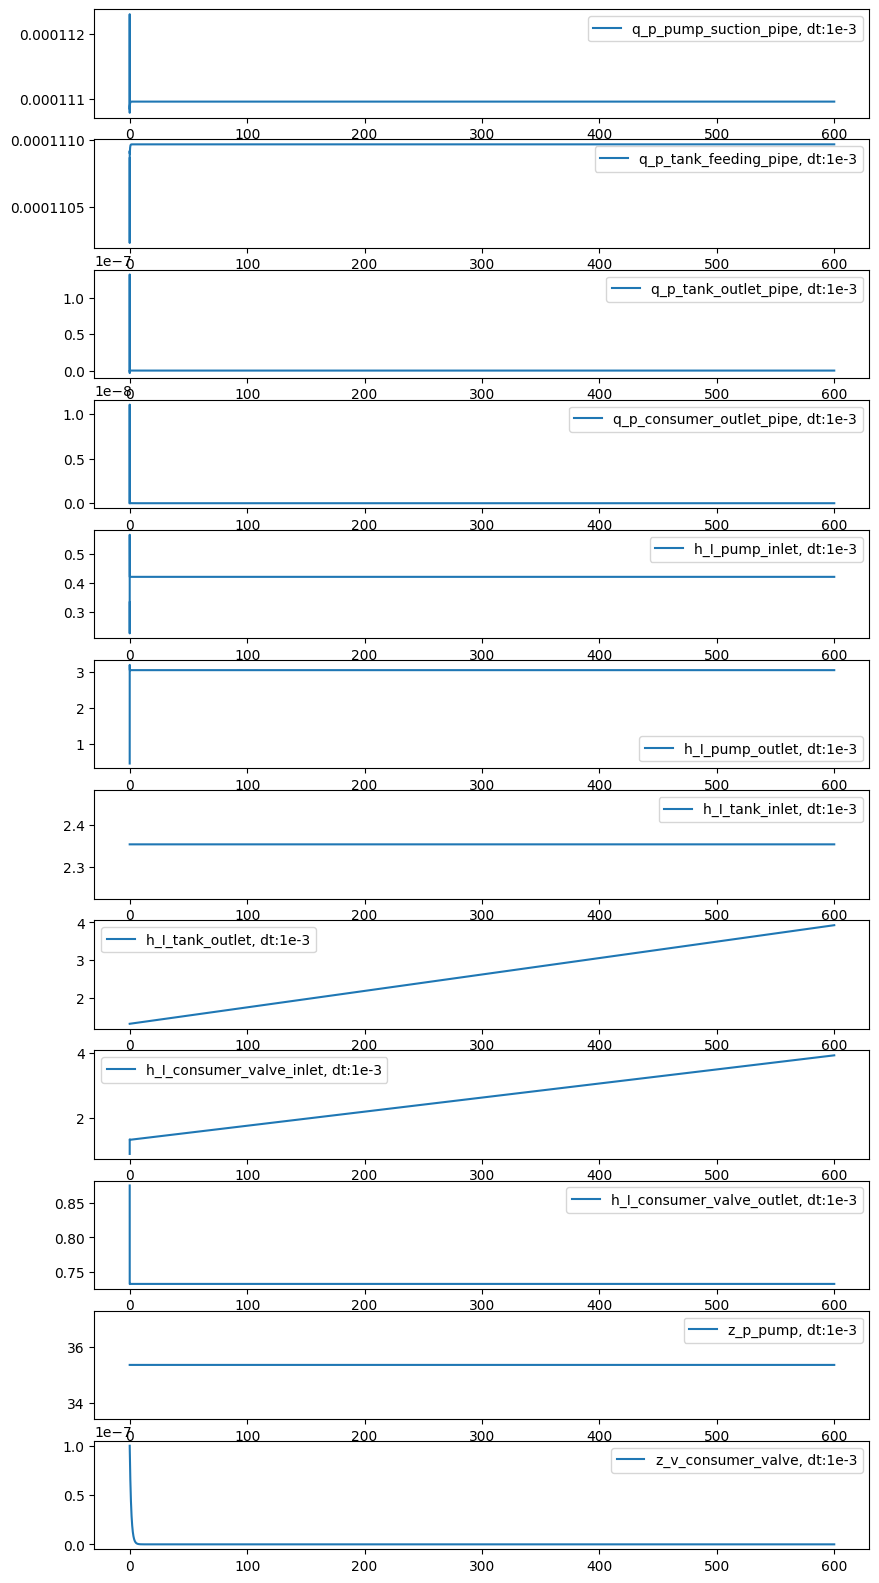

In [12]:
fig, axs = plt.subplots(sys.x.shape[0], figsize=(10, 20))
t = np.arange(t0, t_stop, dt)

for i in range(sys.x.shape[0]):
    axs[i].plot(t_3[:], x_vals_3[:, i], label=sys.x[i].name() + ", dt:1e-3")
    axs[i].legend()

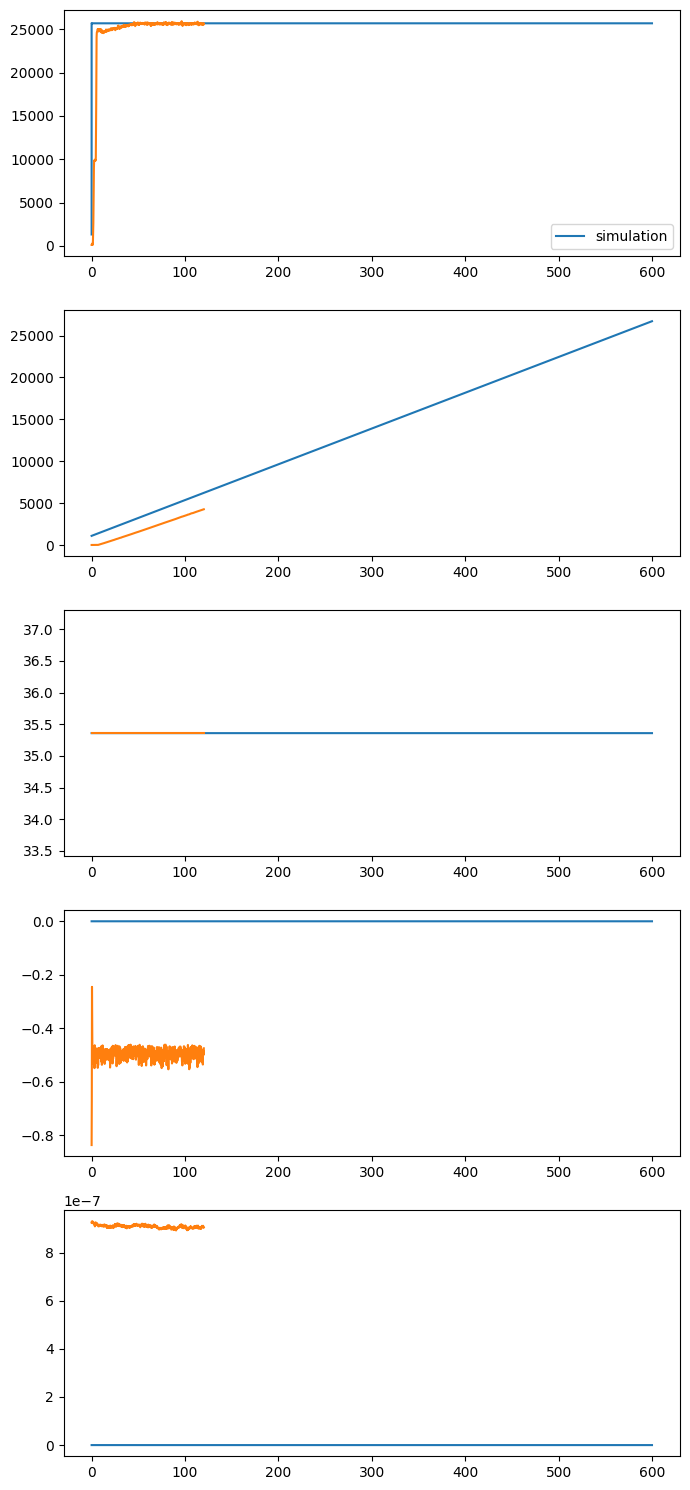

In [13]:
fig, axs = plt.subplots(5, figsize=(7, 15))

axs[0].plot(t_3[:], (x_vals_3[:, 5] - x_vals_3[:, 4]) * rho * g, label="simulation")
plot_results(run.time_series.iloc[:], "time", ["test_rig.pump_1_pressure"], axes=axs[0])
axs[0].legend()

axs[1].plot(
    t_3[:],
    (x_vals_3[:, 7] * rho * g)
    - (
        internal_nodes["tank_outlet"]["elevation"]
        # + internal_nodes["tank_outlet"]["initial_level"]
        # + tank_mean_pressure
    )
    * rho
    * g,
)
plot_results(run.time_series.iloc[:], "time", ["test_rig.tank_1_pressure"], axes=axs[1])

axs[2].plot(t_3[:], x_vals_3[:, 10])
plot_results(
    run.time_series.iloc[:],
    "time",
    ["pump_1.output"],
    axes=axs[2],
)

axs[3].plot(t_3[:], x_vals_3[:, 11] * 100)
plot_results(
    run.time_series.iloc[:],
    "time",
    ["test_rig.consumer_1_valve_opening"],
    axes=axs[3],
)
# for i, ix in enumerate(relevant_x[2:]):
#     axs[i + 1].plot(t_3[:], x_vals_3[:, ix], label=sys.x[ix].name() + ", dt:1e-3")
#     axs[i + 1].legend()

axs[4].plot(t_3[:], ax_vals_3[:, 2], label=sys.ax[2].name())
plot_results(
    run.time_series.iloc[:],
    "time",
    ["test_rig.consumer_1_volume_flow"],
    axes=axs[4],
)
plt.tight_layout()

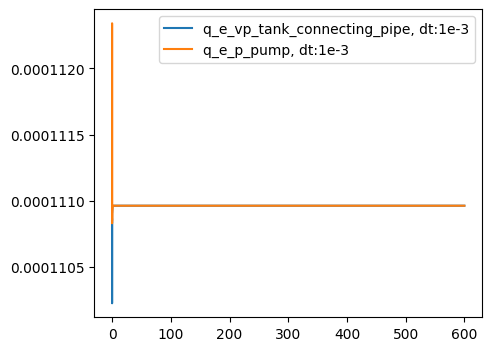

In [14]:
fig, axs = plt.subplots(1, figsize=(5, 4))
t = np.arange(t0, t_stop, dt)

for i in range(2):
    # axs.plot(t_5[:], ax_vals_5[:, i], label=sys.ax[i].name() + ", dt:1e-5")
    # axs.plot(t_4[:], ax_vals_4[:, i], label=sys.ax[i].name() + ", dt:1e-4")
    axs.plot(t_3[:], ax_vals_3[:, i], label=sys.ax[i].name() + ", dt:1e-3")
    axs.legend()

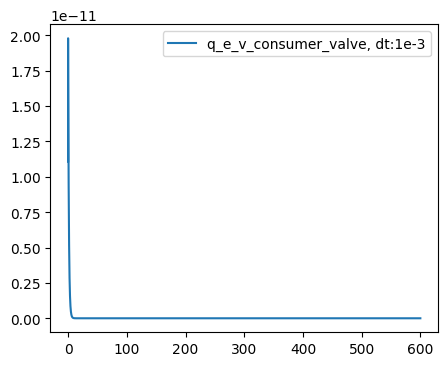

In [15]:
fig, axs = plt.subplots(1, figsize=(5, 4))
t = np.arange(t0, t_stop, dt)

# axs.plot(t_5[:], ax_vals_5[:, 2], label=sys.ax[2].name() + ", dt:1e-5")
# axs.plot(t_4[:], ax_vals_4[:, 2], label=sys.ax[2].name() + ", dt:1e-4")
axs.plot(t_3[:], ax_vals_3[:, 2], label=sys.ax[2].name() + ", dt:1e-3")
axs.legend()

In [16]:
k1

NameError: name 'k1' is not defined

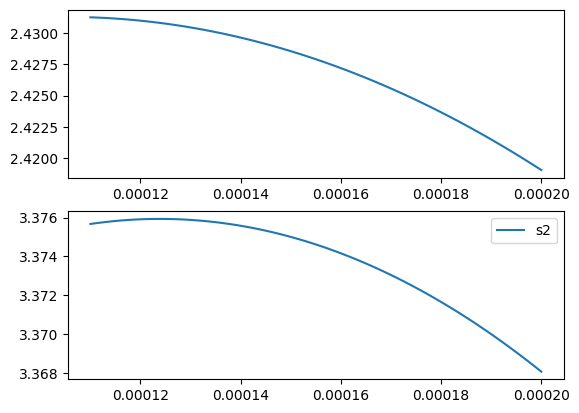

In [ ]:
k1, k2, k3 = pumps["pump"]["head_coefficients"]
s_1 = omega_mean
s_2 = 41.667

fig, axs = plt.subplots(2)

axs[0].plot(
    np.linspace(0.00011, 0.0002, 100),
    [
        (k1 * q**2 + 0.9 * k2 * q * s_1 + k3 * s_1**2)
        for q in np.linspace(0.00011, 0.0002, 100)
    ],
    label="s1",
)
axs[1].plot(
    np.linspace(0.00011, 0.0002, 100),
    [
        (k1 * q**2 + 0.9 * k2 * q * s_2 + k3 * s_2**2)
        for q in np.linspace(0.00011, 0.0002, 100)
    ],
    label="s2",
)
plt.legend()

In [ ]:
q_mean

0.00011085958542333392

In [ ]:
np.pi * 0.18**2 / 4

0.025446900494077322